DOFs per element: 3

Reference mass matrix diagnostics
--------------------------------
shape: (3, 3)
symmetry error: 2.7755575615628914e-17
min eig: 0.10540438266696601
max eig: 0.7000393490456626
rank estimate: 3

Error diagnostics
-----------------
L2-like max error: 2.137311679698109
L2-like mean error: 0.9508185018148305


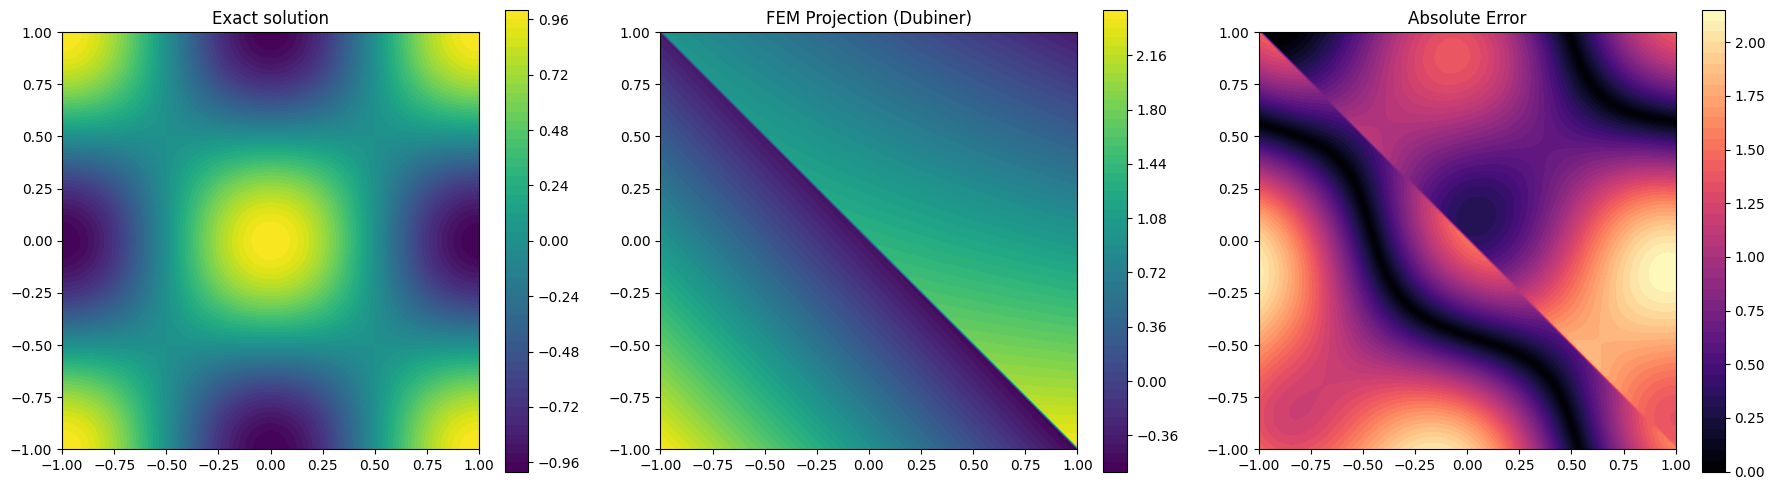

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve

# -----------------------------
# your project imports
# -----------------------------
from localtfem.geometry.structured_mesh import structured_mesh
from localtfem.fem.dof_map import DOFMap
from localtfem.modified_dubiner.dubiner import DubinerBasis
from localtfem.quadrature.reftriquad import RefTriQuad
from localtfem.fem.assembly import assemble_global_matrix, assemble_global_vector

# ============================================================
# 1. SETTINGS
# ============================================================

p = 1
level = -1

mesh = structured_mesh(level)

basis = DubinerBasis(p)
modes = basis.modes
loc_dim = len(modes)

print("DOFs per element:", loc_dim)

# ============================================================
# 2. DOF MAP
# ============================================================

dofmap = DOFMap(p, mesh.nodes, mesh.edges, mesh.elements)
num_dofs = dofmap.ndofs()

# ============================================================
# 3. QUADRATURE (reference triangle)
# ============================================================

R, S, W, XI, ETA = RefTriQuad(p)

R = R.reshape(-1)
S = S.reshape(-1)
W = W.reshape(-1)

# ============================================================
# 4. REFERENCE MASS MATRIX (PURE BASIS CHECK)
# ============================================================

M_ref = np.zeros((loc_dim, loc_dim))

for q in range(len(W)):
    xi, eta, w = R[q], S[q], W[q]

    phi = np.array([m.phi(xi, eta) for m in modes])

    for i in range(loc_dim):
        for j in range(loc_dim):
            M_ref[i, j] += w * phi[i] * phi[j]

# ============================================================
# 4b. MASS MATRIX DIAGNOSTICS (IMPORTANT)
# ============================================================

print("\nReference mass matrix diagnostics")
print("--------------------------------")
print("shape:", M_ref.shape)
print("symmetry error:", np.max(np.abs(M_ref - M_ref.T)))

eigvals = np.linalg.eigvalsh(M_ref)
print("min eig:", np.min(eigvals))
print("max eig:", np.max(eigvals))
print("rank estimate:", np.sum(eigvals > 1e-12))

# ============================================================
# 5. COSINE FUNCTION
# ============================================================

def u_exact(x, y):
    return np.cos(np.pi * x) * np.cos(np.pi * y)

# ============================================================
# 6. LOCAL RHS ASSEMBLY (UNCHANGED FOR NOW)
# ============================================================

num_elems = mesh.num_elements
local_b = np.zeros((num_elems, loc_dim))

for e in range(num_elems):

    verts = mesh.nodes[mesh.elements[e]]

    x0, y0 = verts[0]
    x1, y1 = verts[1]
    x2, y2 = verts[2]

    J = np.array([[x1 - x0, x2 - x0],
                  [y1 - y0, y2 - y0]])
    detJ = abs(np.linalg.det(J))

    for q in range(len(W)):

        xi, eta, w = R[q], S[q], W[q]

        x = x0 + 0.5*(xi + 1)*(x1 - x0) + 0.5*(xi + 1)*(1 - eta)*(x2 - x1)
        y = y0 + 0.5*(xi + 1)*(y1 - y0) + 0.5*(xi + 1)*(1 - eta)*(y2 - y1)

        uq = u_exact(x, y)

        phi = np.array([m.phi(xi, eta) for m in modes])

        for i in range(loc_dim):
            local_b[e, i] += uq * phi[i] * w * detJ

# ============================================================
# 7. GLOBAL ASSEMBLY
# ============================================================

M = assemble_global_matrix(M_ref, mesh.areas, dofmap, num_dofs)
b = assemble_global_vector(local_b, dofmap, num_dofs)

# ============================================================
# 8. SOLVE
# ============================================================

u_h = spsolve(M, b)

# ============================================================
# 8b. VISUALIZATION GRID
# ============================================================

nx = ny = 120
xg = np.linspace(-1, 1, nx)
yg = np.linspace(-1, 1, ny)

X, Y = np.meshgrid(xg, yg)

U_h = np.zeros_like(X)
U_e = np.zeros_like(X)

# ============================================================
# 9. EVALUATION
# ============================================================

for i in range(nx):
    for j in range(ny):

        x, y = X[j, i], Y[j, i]

        for e in range(num_elems):

            v = mesh.nodes[mesh.elements[e]]

            x0, y0 = v[0]
            x1, y1 = v[1]
            x2, y2 = v[2]

            detT = (y1 - y2)*(x0 - x2) + (x2 - x1)*(y0 - y2)

            a = ((y1 - y2)*(x - x2) + (x2 - x1)*(y - y2)) / detT
            b_ = ((y2 - y0)*(x - x2) + (x0 - x2)*(y - y2)) / detT
            c = 1 - a - b_

            if (a >= -1e-12) and (b_ >= -1e-12) and (c >= -1e-12):

                xi = 2*a - 1
                eta = 2*b_ - 1

                loc = dofmap.element_dofs(e)

                uh = 0.0
                for k, m in enumerate(modes):
                    uh += u_h[loc[k]] * m.phi(xi, eta)

                U_h[j, i] = uh
                U_e[j, i] = u_exact(x, y)
                break

ERR = np.abs(U_h - U_e)

print("\nError diagnostics")
print("-----------------")
print("L2-like max error:", np.max(ERR))
print("L2-like mean error:", np.mean(ERR))

# ============================================================
# 10. PLOTS
# ============================================================

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

c0 = ax[0].contourf(X, Y, U_e, 50, cmap="viridis")
ax[0].set_title("Exact solution")
plt.colorbar(c0, ax=ax[0])

c1 = ax[1].contourf(X, Y, U_h, 50, cmap="viridis")
ax[1].set_title("FEM Projection (Dubiner)")
plt.colorbar(c1, ax=ax[1])

c2 = ax[2].contourf(X, Y, ERR, 50, cmap="magma")
ax[2].set_title("Absolute Error")
plt.colorbar(c2, ax=ax[2])

for a in ax:
    a.set_aspect("equal")

plt.tight_layout()
plt.show()